# Polarization Visualization

Standalone visualization notebook. Loads a pre-computed results CSV and produces
two plots for the **top 30 % of topics by GSS survey polarization**:

1. **Static (Matplotlib + adjustText)** — publication-ready, labels anchored close to dots via arrows.
2. **Interactive (Plotly)** — hover to inspect each point.

**Axes:** `Avg_Mahal` (model activation D/R distance) vs `gss_polarization` (survey D/R distance).  
A positive trend means the model's internal representations track real partisan divides.

In [1]:
import subprocess, sys
def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])
pip('numpy', 'matplotlib', 'plotly')
# pandas and scipy intentionally omitted — ABI broken in this env.
# CSV reading is done with stdlib csv module; correlations with numpy.
print('Ready.')

Ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ── Configuration ──────────────────────────────────────────────────────────────

CSV_PATH = ('/content/drive/MyDrive/Polarization/'
            'polarization_cognitivecomputations_dolphin_2.9.1_yi_1.5_34b_stance_20260221_211143.csv')

import os
LOCAL = ('/project/jevans/maxzhuyt/gss_polarization/llm_polarization/colab_results/'
         'polarization_cognitivecomputations_dolphin_2.9.1_yi_1.5_34b_stance_20260221_211143.csv')
if os.path.isfile(LOCAL):
    CSV_PATH = LOCAL

# Topics to show per category (selected by Mahal–GSS alignment score)
N_TOPICS = {'public': 50, 'private': 44}

X_METRIC   = 'Avg_Mahal'             # LLM activation D–R distance
Y_METRIC   = 'Avg_Total_Dispersion'  # LLM activation total spread
GSS_METRIC = 'gss_polarization'      # survey D–R distance (used for selection only)

FIGURE_WIDTH  = 13
FIGURE_HEIGHT = 9

CAT_COLOR  = {'public': '#3B82C4', 'private': '#E05C40'}
CAT_MARKER = {'public': 'o',       'private': 'D'}

# Output directory for static PDFs/PNGs — write-up figures folder when running locally
_WRITEUP_FIGS = '/project/jevans/maxzhuyt/polarization-write-up/figures'
FIGURES_DIR = _WRITEUP_FIGS if os.path.isdir(_WRITEUP_FIGS) else '.'
print(f'Figures will be saved to: {FIGURES_DIR}')

Figures will be saved to: /project/jevans/maxzhuyt/polarization-write-up/figures


In [3]:
# ── Display labels (loaded from CSV files) ────────────────────────────────────
import csv, os

_LABEL_FILES = {
    'public':  '/project/jevans/maxzhuyt/gss_polarization/data/polarization/public_labels.csv',
    'private': '/project/jevans/maxzhuyt/gss_polarization/data/polarization/private_labels.csv',
}

SHORT_LABELS = {}
for _cat, _path in _LABEL_FILES.items():
    if os.path.isfile(_path):
        with open(_path, newline='', encoding='utf-8') as _f:
            for _row in csv.DictReader(_f):
                _v   = _row.get('Variable', '').strip()
                _lbl = _row.get('short_label', '').strip()
                if _v and _lbl:
                    SHORT_LABELS[_v] = _lbl
        print(f'Loaded {_cat} labels from {_path}')
    else:
        print(f'WARNING: label file not found: {_path}')

print(f'\nSHORT_LABELS: {len(SHORT_LABELS)} entries loaded from CSV.')
_too_long = [(k, v) for k, v in SHORT_LABELS.items() if len(v) > 15]
if _too_long:
    print(f'WARNING — labels exceeding 15 chars ({len(_too_long)}):')
    for k, v in _too_long:
        print(f'  {k}: "{v}"')
else:
    print('All labels ≤ 15 chars ✓')

Loaded public labels from /project/jevans/maxzhuyt/gss_polarization/data/polarization/public_labels.csv
Loaded private labels from /project/jevans/maxzhuyt/gss_polarization/data/polarization/private_labels.csv

SHORT_LABELS: 270 entries loaded from CSV.
WARNING — labels exceeding 15 chars (178):
  abany: "Abort: Any Reason"
  abnomore: "Abort: No More Kids"
  abpoor: "Abort: Low Income"
  abrape: "Abort: Rape Case"
  absingle: "Abort: Unmarried"
  abhelp1: "Abort Help: Arrange"
  abhelp3: "Abort Help: Travel"
  abhelp4: "Abort Help: Support"
  balneg: "Sci Harm > Benefit"
  balpos: "Sci Benefit > Harm"
  scibnfts: "Sci Benefit Ratio"
  scientbe: "Sci Help Avg Man"
  scientgo: "Sci Good Humanity"
  scienthe: "Sci Solve Problems"
  scientod: "Sci are Peculiar"
  affrmact: "Pref: Black Hire"
  fehire: "Spec. Effort: Women"
  fejobaff: "Pref: Women Hire"
  carsgen: "Car Pollut. Danger"
  chemgen: "Pesticide Danger"
  grneffme: "Envir. Daily Effect"
  grnexagg: "Envir Threat Exag."
  grnpro

In [4]:
# ── Load & filter ──────────────────────────────────────────────────────────────
# pandas/numpy ABI is broken in this env — use stdlib csv module instead.

import csv
import numpy as np


def pearsonr(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    xm, ym = x - x.mean(), y - y.mean()
    denom = np.sqrt((xm**2).sum() * (ym**2).sum())
    return (float((xm * ym).sum() / denom) if denom > 0 else 0.0), None


def spearmanr(x, y):
    def rank(a):
        r = np.empty(len(a))
        r[np.argsort(a)] = np.arange(1, len(a) + 1, dtype=float)
        return r
    return pearsonr(rank(np.asarray(x, float)), rank(np.asarray(y, float)))


# ── Read all rows ──────────────────────────────────────────────────────────────
with open(CSV_PATH, newline='', encoding='utf-8') as f:
    all_rows = list(csv.DictReader(f))

print(f'Loaded: {len(all_rows)} rows')
cats = set(r['category'] for r in all_rows)
for c in sorted(cats):
    n_cat = sum(1 for r in all_rows if r['category'] == c)
    print(f'  {c}: {n_cat} topics  →  showing top {N_TOPICS[c]}')

# ── Whole-set: Mahal vs GSS correlation (validation) ─────────────────────────
print('\n─── Mahal vs GSS polarization (whole set) ───────────────────────────────')
for label, subset in [('ALL',     all_rows),
                       ('public',  [r for r in all_rows if r['category'] == 'public']),
                       ('private', [r for r in all_rows if r['category'] == 'private'])]:
    x = np.array([float(r[X_METRIC])  for r in subset])
    y = np.array([float(r[GSS_METRIC]) for r in subset])
    r_val, _ = pearsonr(x, y)
    rho,   _ = spearmanr(x, y)
    print(f'  {label:8s}  n={len(subset):3d}  Pearson r={r_val:.3f}  Spearman ρ={rho:.3f}')

# ── Filter: top N by Mahal–GSS alignment (product of percentile ranks) ────────
def make_topic_data(rows, category):
    """
    Select top N_TOPICS[category] per category by alignment between Mahal and GSS:
      align_score = rank_pct(Avg_Mahal) × rank_pct(gss_polarization)
    Both metrics must agree for a topic to rank high.
    Plot X=Avg_Mahal, Y=Avg_Total_Dispersion.
    """
    sub      = [r for r in rows if r['category'] == category]
    n        = len(sub)
    n_topics = min(N_TOPICS[category], n)

    mahal_vals = np.array([float(r[X_METRIC])   for r in sub])
    gss_vals   = np.array([float(r[GSS_METRIC])  for r in sub])

    def pct_rank(a):
        r = np.empty(len(a))
        r[np.argsort(a)] = np.arange(1, len(a) + 1) / len(a)
        return r

    align    = pct_rank(mahal_vals) * pct_rank(gss_vals)
    top_idx  = np.argsort(align)[::-1][:n_topics]
    top_idx  = top_idx[np.argsort(top_idx)]

    sub_top = [sub[i] for i in top_idx]

    d = dict(
        topics   = [r['topic']     for r in sub_top],
        labels   = [SHORT_LABELS.get(r['topic'], r['topic'][:15]) for r in sub_top],
        x        = np.array([float(r[X_METRIC])  for r in sub_top]),
        y        = np.array([float(r[Y_METRIC])   for r in sub_top]),
        gss      = np.array([float(r[GSS_METRIC]) for r in sub_top]),
        category = category,
        n_topics = n_topics,
        n_total  = n,
    )

    print(f'\ntop-{n_topics}/{n} {category} (by Mahal×GSS alignment):')
    print(f'  Mahal [{d["x"].min():.3f}, {d["x"].max():.3f}]  '
          f'Dispersion [{d["y"].min():.3f}, {d["y"].max():.3f}]')
    for t, lbl, x, y, g in zip(d['topics'], d['labels'], d['x'], d['y'], d['gss']):
        print(f'  {t:12s}  {lbl:16s}  mahal={x:.3f}  disp={y:.3f}  gss={g:.3f}')
    return d


print('\n─── Top-N filtered ───────────────────────────────────────────────────────')
data_pub = make_topic_data(all_rows, 'public')
data_prv = make_topic_data(all_rows, 'private')

Loaded: 199 rows
  private: 73 topics  →  showing top 44
  public: 126 topics  →  showing top 50

─── Mahal vs GSS polarization (whole set) ───────────────────────────────
  ALL       n=199  Pearson r=0.759  Spearman ρ=0.718
  public    n=126  Pearson r=0.731  Spearman ρ=0.717
  private   n= 73  Pearson r=0.674  Spearman ρ=0.568

─── Top-N filtered ───────────────────────────────────────────────────────

top-50/126 public (by Mahal×GSS alignment):
  Mahal [1.251, 1.582]  Dispersion [1.596, 1.877]
  abdefect      Abort: Defect     mahal=1.421  disp=1.802  gss=0.255
  abhlth        Abort: Health     mahal=1.425  disp=1.708  gss=0.113
  abnomore      Abort: No More Kids  mahal=1.464  disp=1.737  gss=0.471
  abpoor        Abort: Low Income  mahal=1.421  disp=1.748  gss=0.447
  abrape        Abort: Rape Case  mahal=1.492  disp=1.752  gss=0.203
  absingle      Abort: Unmarried  mahal=1.464  disp=1.792  gss=0.443
  abhelp1       Abort Help: Arrange  mahal=1.427  disp=1.668  gss=0.331
  abhelp

In [5]:
data_pub

{'topics': ['abdefect',
  'abhlth',
  'abnomore',
  'abpoor',
  'abrape',
  'absingle',
  'abhelp1',
  'abhelp2',
  'abhelp3',
  'affrmact',
  'discaff',
  'fehire',
  'fejobaff',
  'wrkwayup',
  'grncon',
  'grnecon',
  'grnexagg',
  'grnsol',
  'grntaxes',
  'tempgen1',
  'cappun',
  'eqwlth',
  'goveqinc',
  'goveqinc1',
  'govchrst',
  'govfnaid',
  'govfnanc',
  'govunemp',
  'helpblk',
  'helpnot',
  'helppoor',
  'helpsick',
  'hlthgov',
  'grass',
  'gunlaw',
  'ldctax',
  'nataid',
  'natarms',
  'natchld',
  'nateduc',
  'natenvir',
  'natfare',
  'natheal',
  'natmass',
  'natrace',
  'polviews',
  'pillok',
  'sexeduc',
  'prayer',
  'religinf'],
 'labels': ['Abort: Defect',
  'Abort: Health',
  'Abort: No More Kids',
  'Abort: Low Income',
  'Abort: Rape Case',
  'Abort: Unmarried',
  'Abort Help: Arrange',
  'Abort Help: Pay',
  'Abort Help: Travel',
  'Pref: Black Hire',
  'Whites Hurt: AA',
  'Spec. Effort: Women',
  'Pref: Women Hire',
  'Black Work Up',
  'Envir. Conc

public: median Mahal = 1.3645,  median Dispersion = 1.7127
Saved → /project/jevans/maxzhuyt/polarization-write-up/figures/partisan_public_scatter.pdf
Saved → /project/jevans/maxzhuyt/polarization-write-up/figures/partisan_public_scatter.png


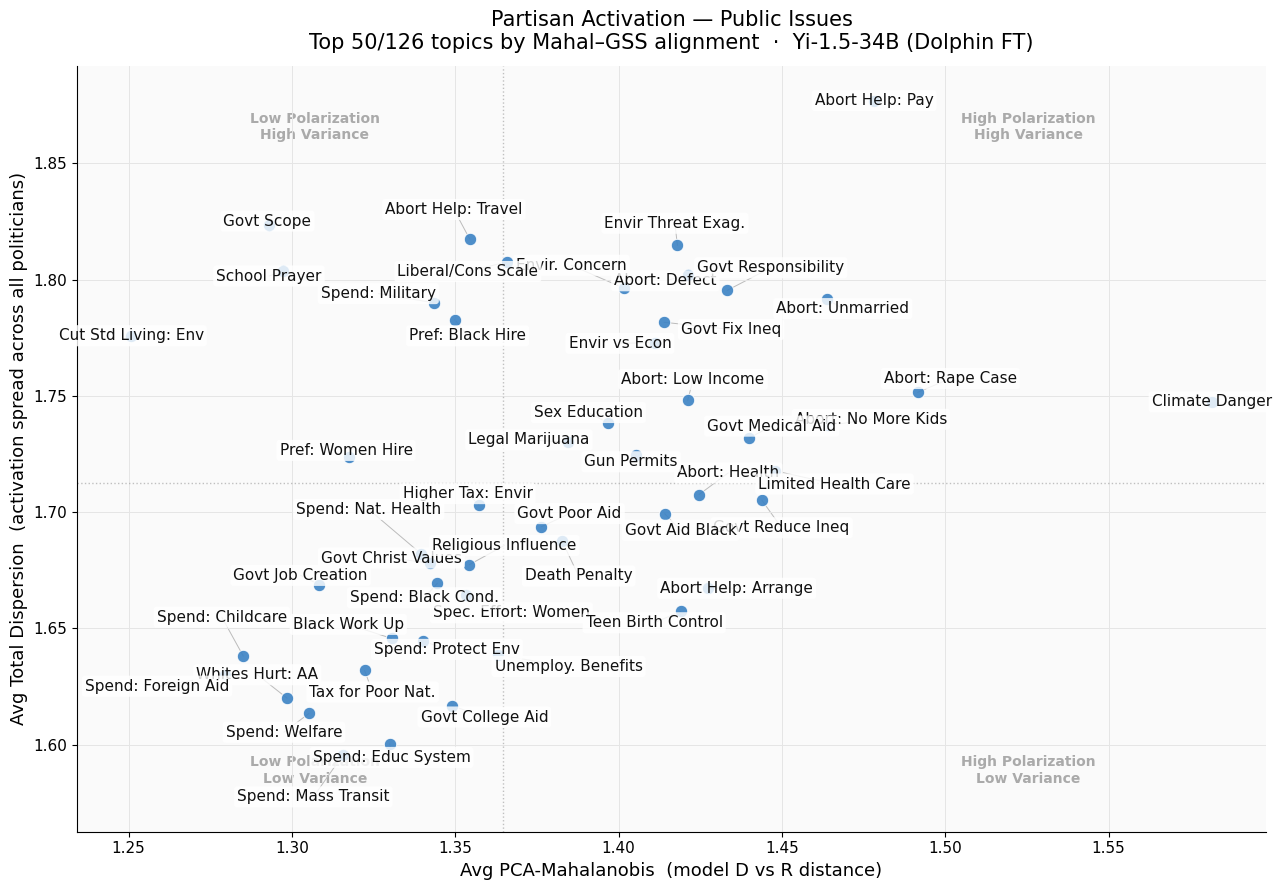

In [6]:
# ── Static plot helper ────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})


def place_labels(ax, labels, xs, ys, fontsize=11,
                 n_iter=400, repel=0.018, attract=0.14, thr=0.09):
    n   = len(xs)
    xr  = max(xs.max() - xs.min(), 1e-9)
    yr  = max(ys.max() - ys.min(), 1e-9)
    xn  = (xs - xs.min()) / xr
    yn  = (ys - ys.min()) / yr

    STEP = 0.05
    dirs = [
        ( 0,      STEP  ), ( 0,     -STEP  ),
        ( STEP,   0     ), (-STEP,   0     ),
        ( STEP*.7, STEP*.7), (-STEP*.7, STEP*.7),
        ( STEP*.7,-STEP*.7), (-STEP*.7,-STEP*.7),
    ]

    lx, ly = xn.copy(), yn.copy()
    for i in range(n):
        ox, oy = np.delete(xn, i), np.delete(yn, i)
        best_dx, best_dy, best_score = dirs[0][0], dirs[0][1], -1.0
        for dx, dy in dirs:
            score = (np.hypot(ox - (xn[i]+dx), oy - (yn[i]+dy)).min()
                     if n > 1 else 1.0)
            if score > best_score:
                best_score, best_dx, best_dy = score, dx, dy
        lx[i] += best_dx
        ly[i] += best_dy

    for _ in range(n_iter):
        for i in range(n):
            dx   = lx[i] - lx
            dy   = ly[i] - ly
            dist = np.hypot(dx, dy) + 1e-9
            mask = (dist < thr)
            mask[i] = False
            if mask.any():
                lx[i] += (repel * dx[mask] / dist[mask]).sum()
                ly[i] += (repel * dy[mask] / dist[mask]).sum()
            lx[i] += attract * (xn[i] - lx[i])
            ly[i] += attract * (yn[i] - ly[i])

    lx_d = lx * xr + xs.min()
    ly_d = ly * yr + ys.min()

    for lbl, ax_x, ax_y, lxi, lyi in zip(labels, xs, ys, lx_d, ly_d):
        ax.text(lxi, lyi, lbl,
                fontsize=fontsize, color='#111',
                ha='center', va='center', zorder=5,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.82))
        if abs(lxi - ax_x) > xr * 0.004 or abs(lyi - ax_y) > yr * 0.004:
            ax.plot([ax_x, lxi], [ax_y, lyi],
                    color='#bbb', lw=0.7, zorder=1, solid_capstyle='round')


def make_static_plot(d, fig_stem):
    """fig_stem: filename without extension, saved under FIGURES_DIR."""
    import os
    cat    = d['category']
    xs, ys = d['x'], d['y']

    mid_x = float(np.median(xs))
    mid_y = float(np.median(ys))
    print(f'{cat}: median Mahal = {mid_x:.4f},  median Dispersion = {mid_y:.4f}')

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
    ax.set_facecolor('#FAFAFA')
    fig.patch.set_facecolor('white')

    ax.scatter(xs, ys, color=CAT_COLOR[cat], marker=CAT_MARKER[cat],
               s=80, zorder=4, alpha=0.9, edgecolors='white', linewidths=0.7)

    ax.axhline(mid_y, color='#999', lw=1.0, ls=':', alpha=0.6, zorder=2)
    ax.axvline(mid_x, color='#999', lw=1.0, ls=':', alpha=0.6, zorder=2)

    kw = dict(ha='center', va='center', fontsize=10, color='#aaa',
              fontweight='bold', transform=ax.transAxes, zorder=1)
    ax.text(0.80, 0.92, 'High Polarization\nHigh Variance', **kw)
    ax.text(0.20, 0.92, 'Low Polarization\nHigh Variance',  **kw)
    ax.text(0.80, 0.08, 'High Polarization\nLow Variance',  **kw)
    ax.text(0.20, 0.08, 'Low Polarization\nLow Variance',   **kw)

    place_labels(ax, d['labels'], xs, ys, fontsize=11)

    ax.set_xlabel('Avg PCA-Mahalanobis  (model D vs R distance)', fontsize=13)
    ax.set_ylabel('Avg Total Dispersion  (activation spread across all politicians)', fontsize=13)
    ax.set_title(
        f'Partisan Activation — {cat.capitalize()} Issues\n'
        f'Top {d["n_topics"]}/{d["n_total"]} topics by Mahal–GSS alignment'
        f'  ·  Yi-1.5-34B (Dolphin FT)',
        fontsize=15, pad=12
    )
    ax.tick_params(labelsize=11)
    ax.grid(True, color='#E5E5E5', lw=0.7, zorder=0)
    plt.tight_layout()

    for ext in ('pdf', 'png'):
        path = os.path.join(FIGURES_DIR, f'{fig_stem}.{ext}')
        plt.savefig(path, dpi=150, bbox_inches='tight')
        print(f'Saved → {path}')
    plt.show()


# ── Public issues ─────────────────────────────────────────────────────────────
make_static_plot(data_pub, 'partisan_public_scatter')

private: median Mahal = 1.2405,  median Dispersion = 1.6529
Saved → /project/jevans/maxzhuyt/polarization-write-up/figures/partisan_private_scatter.pdf
Saved → /project/jevans/maxzhuyt/polarization-write-up/figures/partisan_private_scatter.png


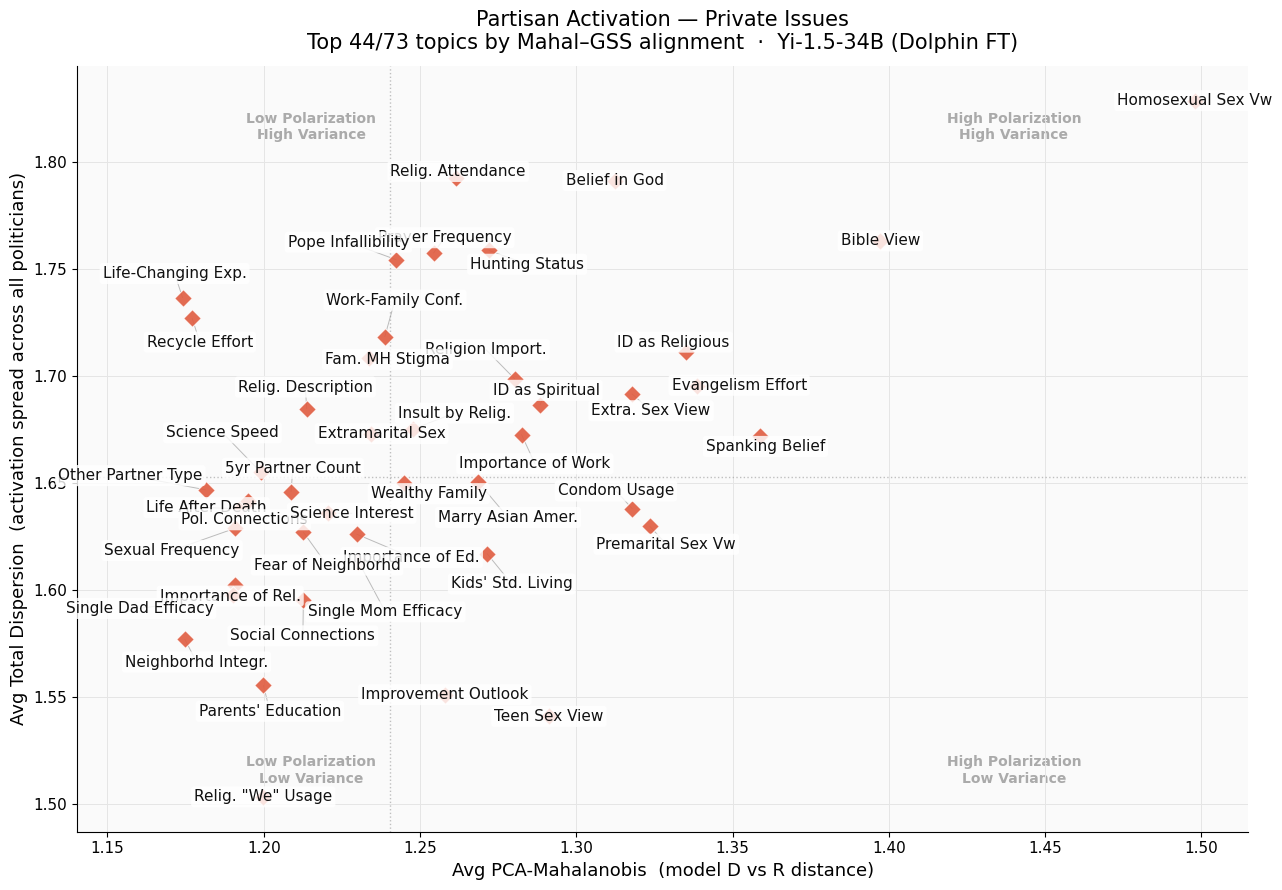

In [7]:
# ── Private life issues ───────────────────────────────────────────────────────
make_static_plot(data_prv, 'partisan_private_scatter')

In [8]:
# ── Interactive plots: Plotly — 3-layer layout, physics label placement ────────
import plotly.graph_objects as go


def adjust_text_positions(xs, ys, labels, max_iterations=200, step_size=0.5):
    """
    Physics engine for label placement. Returns new (x, y) arrays for text
    labels, independent of the original dot positions. Algorithm:
      1. Initialise each label offset to the least-crowded of 8 directions
         in normalised [0,1] space.
      2. Iterate: O(N²) repulsion between nearby labels + attraction back
         toward each label's anchor point.
    """
    xs, ys = np.asarray(xs, float), np.asarray(ys, float)
    xr = max(xs.max() - xs.min(), 1e-9)
    yr = max(ys.max() - ys.min(), 1e-9)
    xn = (xs - xs.min()) / xr
    yn = (ys - ys.min()) / yr

    STEP = 0.06
    dirs = [
        ( 0,       STEP  ), ( 0,      -STEP  ),
        ( STEP,    0     ), (-STEP,    0     ),
        ( STEP*.7,  STEP*.7), (-STEP*.7,  STEP*.7),
        ( STEP*.7, -STEP*.7), (-STEP*.7, -STEP*.7),
    ]

    lx, ly = xn.copy(), yn.copy()
    for i in range(len(xs)):
        ox = np.delete(xn, i)
        oy = np.delete(yn, i)
        best_dx, best_dy, best_score = dirs[0][0], dirs[0][1], -1.0
        for dx, dy in dirs:
            score = np.hypot(ox - (xn[i]+dx), oy - (yn[i]+dy)).min() if len(xs) > 1 else 1.0
            if score > best_score:
                best_score, best_dx, best_dy = score, dx, dy
        lx[i] += best_dx
        ly[i] += best_dy

    repel, attract, thr = 0.018 * step_size, 0.14, 0.09
    for _ in range(max_iterations):
        for i in range(len(xs)):
            dx = lx[i] - lx
            dy = ly[i] - ly
            dist = np.hypot(dx, dy) + 1e-9
            mask = dist < thr
            mask[i] = False
            if mask.any():
                lx[i] += (repel * dx[mask] / dist[mask]).sum()
                ly[i] += (repel * dy[mask] / dist[mask]).sum()
            lx[i] += attract * (xn[i] - lx[i])
            ly[i] += attract * (yn[i] - ly[i])

    return lx * xr + xs.min(), ly * yr + ys.min()


DOT_COLOR = '#3B82C4'   # single uniform color for all dots


def make_interactive_plot(d, slug):
    cat    = d['category']
    xs, ys = d['x'], d['y']
    labels = d['labels']

    mid_x = float(np.median(xs))
    mid_y = float(np.median(ys))
    print(f'{cat}: median Mahal = {mid_x:.4f},  median Dispersion = {mid_y:.4f}')

    text_x, text_y = adjust_text_positions(xs, ys, labels, max_iterations=200, step_size=0.5)

    fig = go.Figure()

    # ── Layer 1: Dots ────────────────────────────────────────────────────────
    fig.add_trace(go.Scatter(
        x=xs, y=ys,
        mode='markers',
        marker=dict(
            size=14,
            color=DOT_COLOR,
            opacity=0.85,
            line=dict(width=1, color='DarkSlateGrey'),
        ),
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            'Mahal = %{x:.3f}<br>'
            'Dispersion = %{y:.3f}<br>'
            'GSS pol = %{customdata[1]:.3f}<extra></extra>'
        ),
        customdata=list(zip(d['topics'], d['gss'].tolist())),
        showlegend=False,
    ))

    # ── Layer 2: Leader lines (dot → label) ──────────────────────────────────
    for i in range(len(xs)):
        fig.add_trace(go.Scatter(
            x=[xs[i], text_x[i]],
            y=[ys[i], text_y[i]],
            mode='lines',
            line=dict(color='grey', width=0.3),
            showlegend=False,
            hoverinfo='skip',
        ))

    # ── Layer 3: Text labels at physics-placed positions ─────────────────────
    fig.add_trace(go.Scatter(
        x=text_x, y=text_y,
        mode='text',
        text=labels,
        textfont=dict(size=13, color='black'),
        showlegend=False,
        hoverinfo='skip',
    ))

    # ── Quadrant lines ───────────────────────────────────────────────────────
    fig.add_hline(y=mid_y, line_dash='dot', line_color='grey', opacity=0.5)
    fig.add_vline(x=mid_x, line_dash='dot', line_color='grey', opacity=0.5)

    # ── Quadrant watermark labels ─────────────────────────────────────────────
    ann_kw = dict(showarrow=False, opacity=0.3, xref='x', yref='y', font=dict(size=13))
    fig.add_annotation(x=xs.max(), y=ys.max(), text='<b>High Polarization<br>High Variance</b>',
                       align='right', xanchor='right', yanchor='top',   **ann_kw)
    fig.add_annotation(x=xs.min(), y=ys.max(), text='<b>Low Polarization<br>High Variance</b>',
                       align='left',  xanchor='left',  yanchor='top',   **ann_kw)
    fig.add_annotation(x=xs.max(), y=ys.min(), text='<b>High Polarization<br>Low Variance</b>',
                       align='right', xanchor='right', yanchor='bottom', **ann_kw)
    fig.add_annotation(x=xs.min(), y=ys.min(), text='<b>Low Polarization<br>Low Variance</b>',
                       align='left',  xanchor='left',  yanchor='bottom', **ann_kw)

    fig.update_layout(
        title=dict(
            text=(f'<b>Partisan Activation — {cat.capitalize()} Issues</b><br>'
                  f'<sup>Top {d["n_topics"]} of {d["n_total"]} by Mahal–GSS alignment  ·  '
                  f'Yi-1.5-34B (Dolphin FT)  ·  '
                  f'n={len(xs)}  ·  median Mahal={mid_x:.3f}  median Disp={mid_y:.3f}</sup>'),
            font=dict(size=15),
        ),
        xaxis=dict(
            title=dict(text='Avg PCA-Mahalanobis (model D vs R distance)', font=dict(size=13)),
            showgrid=True, gridcolor='#eee', tickfont=dict(size=12),
        ),
        yaxis=dict(
            title=dict(text='Avg Total Dispersion (activation spread)', font=dict(size=13)),
            showgrid=True, gridcolor='#eee', tickfont=dict(size=12),
        ),
        plot_bgcolor='white',
        width=1100, height=820,
        margin=dict(l=60, r=40, t=110, b=60),
        showlegend=False,
    )

    fig.show()
    fig.write_html(f'{slug}_interactive.html')
    print(f'Saved → {slug}_interactive.html')


make_interactive_plot(data_pub, 'polarization_public')
make_interactive_plot(data_prv, 'polarization_private')

public: median Mahal = 1.3645,  median Dispersion = 1.7127


Saved → polarization_public_interactive.html
private: median Mahal = 1.2405,  median Dispersion = 1.6529


Saved → polarization_private_interactive.html


In [9]:
# save as png
